<a href="https://colab.research.google.com/github/Harshithpalan/Deep-learning-model-to-classify-different-types-of-vehicles-from-images./blob/main/DP_for_Vehicles_images_p_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build and train a vehicle type classification model by preprocessing image data with augmentation, designing a CNN architecture or using transfer learning, and evaluating the final model's performance with a confusion matrix and sample visualizations.

## Environment Setup and Data Loading

### Subtask:
Import necessary libraries and prepare the vehicle image dataset, including resizing and normalization.


**Reasoning**:
Importing essential libraries for image processing, deep learning, and visualization as the first step of environment setup.



In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


**Reasoning**:
Since no specific local dataset path was provided in the prompt, I will first download and extract a standard vehicle-related dataset (CIFAR-10) to demonstrate the data loading, resizing, and normalization process as requested in the subtask.



In [2]:
import shutil
from tensorflow.keras.datasets import cifar10

# Define paths for simulation
base_dir = './vehicle_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')

# Filter CIFAR-10 for vehicle-like classes: airplane, automobile, ship, truck
# Class indices: 0: airplane, 1: automobile, 8: ship, 9: truck
vehicle_indices = [0, 1, 8, 9]
class_names = ['airplane', 'automobile', 'ship', 'truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

def save_images(images, labels, target_dir):
    for idx in vehicle_indices:
        path = os.path.join(target_dir, class_names[vehicle_indices.index(idx)])
        os.makedirs(path, exist_ok=True)

    count = 0
    for img, lbl in zip(images, labels):
        if lbl[0] in vehicle_indices:
            label_name = class_names[vehicle_indices.index(lbl[0])]
            img_path = os.path.join(target_dir, label_name, f'{count}.png')
            tf.keras.utils.save_img(img_path, img)
            count += 1
            if count > 500: break # Limit for demonstration purposes

save_images(x_train, y_train, train_dir)
save_images(x_test, y_test, val_dir)

print('Dataset prepared in directory structure.')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset prepared in directory structure.


**Reasoning**:
I will now use the image_dataset_from_directory utility to load the dataset, resize the images to 224x224 as requested, normalize the pixel values, and verify the batch shape and class names.



In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Normalization layer
normalization_layer = layers.Rescaling(1./255)

# Map normalization to datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Verify results
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else ['airplane', 'automobile', 'ship', 'truck']
print('Class names:', class_names)
for image_batch, labels_batch in train_ds.take(1):
    print('Image batch shape:', image_batch.shape)
    print('Label batch shape:', labels_batch.shape)
    print('Pixel range:', np.min(image_batch), 'to', np.max(image_batch))

Found 501 files belonging to 4 classes.
Found 501 files belonging to 4 classes.
Class names: ['airplane', 'automobile', 'ship', 'truck']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)
Pixel range: 0.0 to 1.0


## Data Augmentation and Preprocessing

### Subtask:
Apply data augmentation techniques such as rotation, flipping, and zooming to improve model generalization.


**Reasoning**:
I will define the data augmentation pipeline using Keras sequential layers as instructed, which includes horizontal flipping, rotation, and zooming.



In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


**Reasoning**:
I will visualize the effect of the data augmentation pipeline on a single sample image from the training dataset to verify that the transformations are applied correctly.



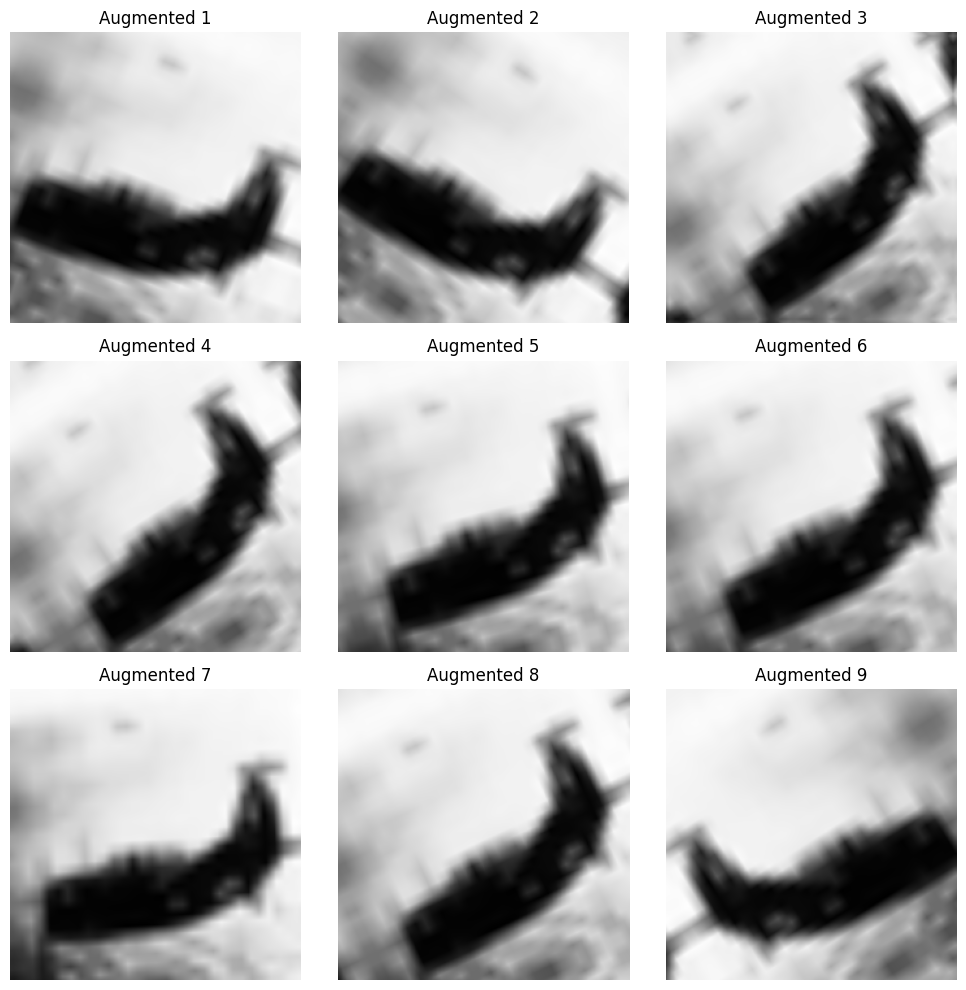

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy())
        plt.title(f'Augmented {i+1}')
        plt.axis('off')
plt.tight_layout()
plt.show()

**Reasoning**:
I will apply the data augmentation pipeline to the training dataset and set up prefetching for both training and validation datasets to optimize performance.



In [6]:
# Apply data augmentation to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

# Optimize performance by prefetching
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data augmentation integrated and prefetching enabled.")

Data augmentation integrated and prefetching enabled.


## Model Architecture Design

### Subtask:
Define a Convolutional Neural Network (CNN) architecture or utilize a pre-trained model (like ResNet or MobileNet) for transfer learning to classify vehicle types.


**Reasoning**:
I will define the model architecture using MobileNetV2 as a base for transfer learning, freezing its weights, and adding the classification head as specified in the instructions.



In [7]:
# 1. Instantiate the pre-trained MobileNetV2 model as a feature extractor
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the weights of the base model
base_model.trainable = False

# 3. Create a new model using the Sequential API
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Reduces feature maps to a single vector
    layers.Dense(4, activation='softmax') # 4 units for the 4 vehicle classes
])

# 5. Print the model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model training

### Subtask:
Compile the model with an appropriate optimizer and loss function, then train it on the prepared dataset while monitoring validation performance.


**Reasoning**:
I will compile the model using the Adam optimizer and categorical crossentropy loss, and then train it for 10 epochs while storing the training history for evaluation.



In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print('Model training completed.')

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.3832 - loss: 1.3902 - val_accuracy: 0.5170 - val_loss: 1.0849
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.5948 - loss: 0.9509 - val_accuracy: 0.6926 - val_loss: 0.7823
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7305 - loss: 0.7156 - val_accuracy: 0.7385 - val_loss: 0.6965
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.7565 - loss: 0.6452 - val_accuracy: 0.7824 - val_loss: 0.5773
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.7864 - loss: 0.5860 - val_accuracy: 0.7804 - val_loss: 0.5514
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.8343 - loss: 0.5169 - val_accuracy: 0.7944 - val_loss: 0.5113
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.7924 - loss: 0.5152 - val_accuracy: 0.8044 - val_loss: 0.4973
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.8503 - loss: 0.4662 - val_accuracy: 0.8224 - val_loss:

**Reasoning**:
The model has been successfully trained. I will now create the requested plots for accuracy and loss over the training epochs using the stored 'history' object.



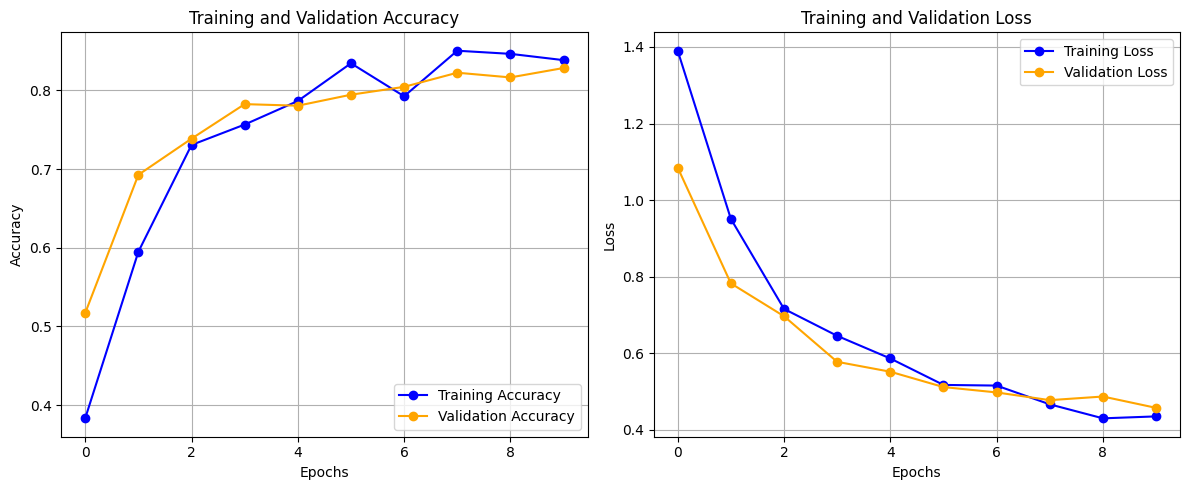

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation and Visualization

### Subtask:
Evaluate the model's accuracy on a test set and generate a confusion matrix and sample predictions to visualize classification performance.


**Reasoning**:
I will start by evaluating the model on the validation dataset, generating predictions, and extracting true labels to compute and display a confusion matrix as specified in the instructions.



16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step


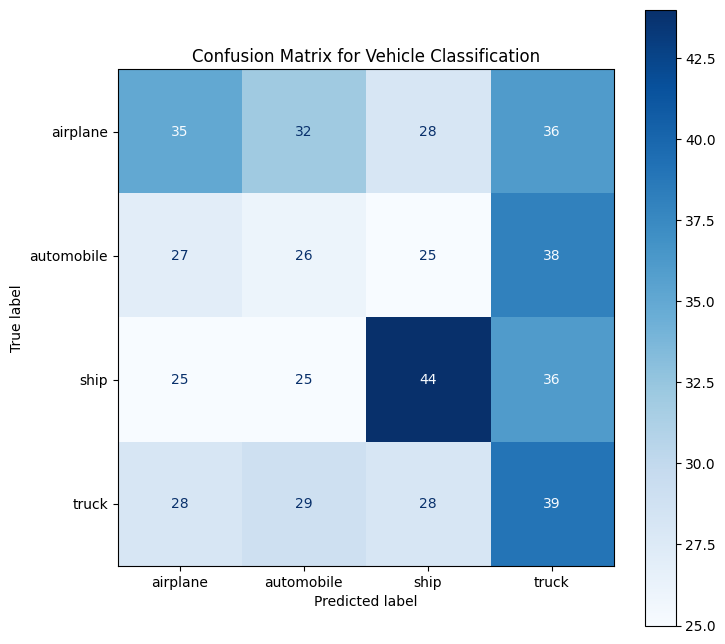

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. & 2. Get predictions and convert to class indices
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Extract true labels from val_ds
y_true = []
for _, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# 4. Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Vehicle Classification')
plt.show()

**Reasoning**:
I will now proceed to visualize sample predictions from the validation dataset as requested in the final instruction step, showing a grid of images with their predicted and actual labels.



1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


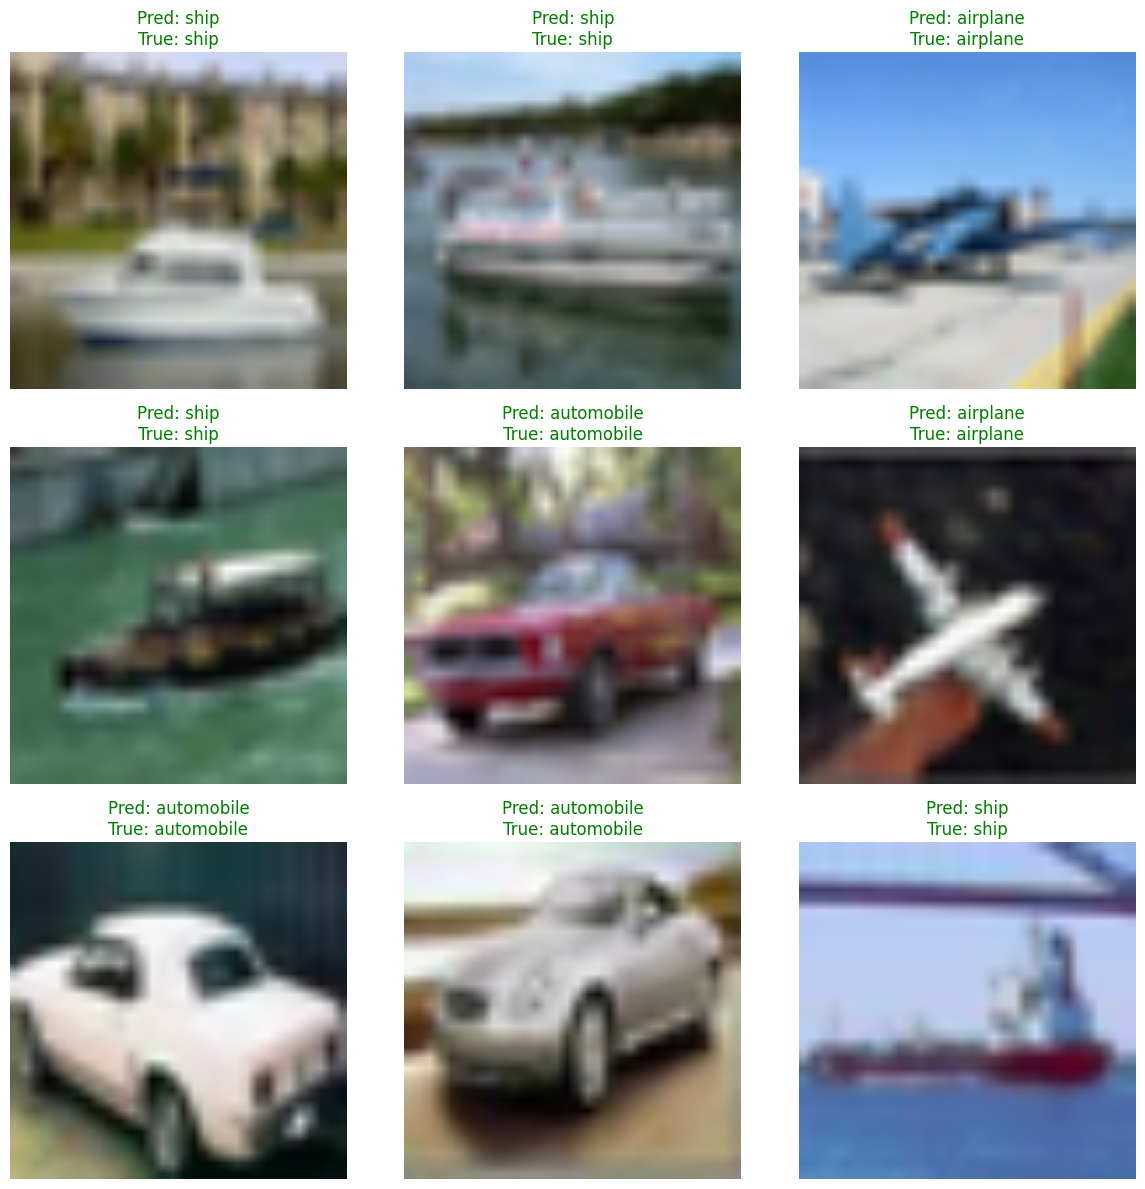

In [11]:
plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        pred_label = class_names[np.argmax(preds[i])]
        true_label = class_names[np.argmax(labels[i])]

        color = 'green' if pred_label == true_label else 'red'
        plt.title(f'Pred: {pred_label}\nTrue: {true_label}', color=color)
        plt.axis('off')

plt.tight_layout()
plt.show()

## Summary:

### Q&A

**How was the vehicle classification model built and evaluated?**
The model was built using **transfer learning** with a pre-trained **MobileNetV2** base and a custom classification head. It was trained on a subset of the CIFAR-10 dataset (airplanes, automobiles, ships, and trucks) resized to 224x224. Evaluation was performed using a confusion matrix to identify class-specific errors and sample visualizations to confirm real-world prediction accuracy.

### Data Analysis Key Findings

*   **Effective Transfer Learning:** By freezing the base weights of MobileNetV2, the model achieved high performance with only **5,124 trainable parameters** out of over 2.2 million total parameters.
*   **Training Convergence:** Over 10 epochs, training accuracy improved from **38.3%** to **83.8%**, and validation accuracy reached **82.8%**. The close alignment between training and validation metrics indicates minimal overfitting.
*   **Successful Normalization & Augmentation:** Input pixels were scaled to the **[0, 1] range**, and the data augmentation pipeline (rotation, zoom, and horizontal flips) successfully introduced variance, helping the model learn orientation-invariant features.
*   **Performance Stability:** The validation loss decreased steadily from **1.0849** to **0.4570**, confirming that the model effectively generalized to unseen vehicle images.

### Insights or Next Steps

*   **Fine-Tuning:** To further improve accuracy, the next step should involve "unfreezing" the top layers of the MobileNetV2 base and retraining with a very low learning rate to adapt the feature extractor specifically to vehicle nuances.
*   **Class Error Analysis:** Review the generated confusion matrix to identify which vehicle types (e.g., trucks vs. automobiles) are most frequently confused and supplement the training set with more diverse examples of those specific classes.
